# K-means and GMM with EM step

### Data Science Problem :

Suppose you have a dataset with two types of customer (Budget Friendly and primium customer).You need to create cluster to find out which customer belongs to which custmer. On the basis of this model, if a new customer added, you need to find out, if the custmer is coming under budget friendly or primium level customer.

### Solution :

First we will create cluster and find out which data points belongs to which customer level.
Here we can use two clustering (hard and soft), so that we can compare and check which cluster we should use to level customer.

#### K-Means (Hard Clustering): 
Uses Euclidean distance to assign points to the nearest centroid. It assumes clusters are spherical and have equal variance. If a customer is slightly closer to the "Budget" center in terms of raw distance, they are 100% assigned there, ignoring the "spread" of the Premium group. 
#### GMM (Soft Clustering): 
Uses Probability Distributions (Gaussians). It considers both the mean and the variance (width). A GMM might recognize that the "Premium" cluster is much wider. Therefore, a data point could have a higher probability of belonging to the wide Premium cluster than the dense Budget cluster, even if it is physically closer to the Budget center. 

### 1. Import library and Data
# -------------------------------------------

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from matplotlib.colors import LogNorm
from sklearn.metrics import silhouette_score


# 1. Load the dataset (Assumes the CSV was generated previously)
try:
    df = pd.read_csv('customer_dataset.csv')
except FileNotFoundError:
    # Fallback: Generate data if file is missing
    np.random.seed(42)
    budget = np.random.multivariate_normal(mean=[20, 7], cov=[[4, 0], [0, 0.25]], size=150)
    premium = np.random.multivariate_normal(mean=[85, 4], cov=[[400, 0], [0, 4]], size=150)
    X_gen = np.vstack([budget, premium])
    df = pd.DataFrame(X_gen, columns=['Annual Spend (k$)', 'Purchase Frequency (Score)'])



In [2]:
# Extract features for clustering
X = df[['Annual Spend (k$)', 'Purchase Frequency (Score)']].values

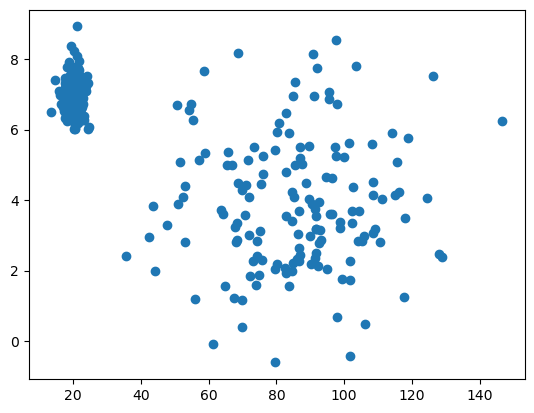

In [3]:
df_dataframe = pd.DataFrame(df,columns=['Annual Spend (k$)','Purchase Frequency (Score)'])
plt.scatter(df_dataframe ['Annual Spend (k$)'],df_dataframe['Purchase Frequency (Score)'])

### 2. APPLY K-MEANS (Euclidean/Distance Logic)
# -------------------------------------------


In [4]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X)

# Assign labels back to dataframe
df['KMeans_Labels'] = kmeans.labels_

In [5]:
df.head()

,Annual Spend (k$),Purchase Frequency (Score),True Label,KMeans_Labels
0,20.993428,6.930868,Budget Friendly,0
1,21.295377,7.761515,Budget Friendly,0
2,19.531693,6.882932,Budget Friendly,0
3,23.158426,7.383717,Budget Friendly,0
4,19.061051,7.271280,Budget Friendly,0


### WCSS (Within-Cluster Sum of Squares)

#### Definition: 
WCSS measures the Inertia of a cluster. It quantifies how tightly packed the data points are around their respective centroid. The lower the WCSS, the more "dense" the cluster is.

#### The Function:
For a cluster C with centroid μ, the WCSS is the sum of the squared Euclidean distances:
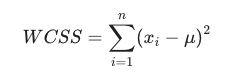



#### Example

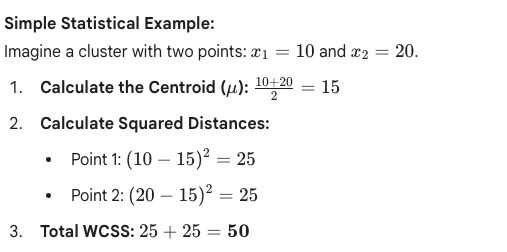

### Silhouette Coefficient

#### Definition: 
The Silhouette score measures how well a point "fits" its own cluster compared to how much it "leaks" into the next nearest cluster. It balances Cohesion (A) and Separation (B).

#### The Function:
For a single point i:
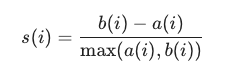

a(i): Average distance to all points in the same cluster.

b(i): Average distance to all points in the nearest neighbor cluster.

#### Silhouette score :
Near +1: The point is far away from the neighboring cluster (Excellent).

Near 0: The point is on the decision boundary between two clusters (Indifferent).

Near -1: The point might be assigned to the wrong cluster (Bad).

#### Example

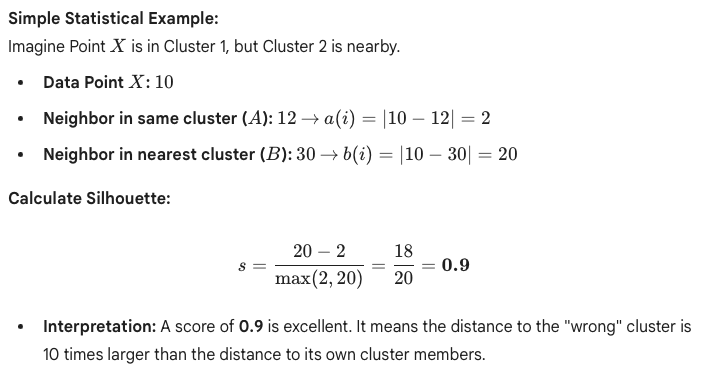

#### Why do we use both?

If you only look at WCSS, you might choose too many clusters (because more clusters always mean lower WCSS). By checking the Silhouette, you ensure that those clusters aren't just tight, but also distinct from one another.

#### Within-Cluster Sum of Squares(WCSS)

In [6]:

X = df[['Annual Spend (k$)', 'Purchase Frequency (Score)']].values

# Calculate Within-Cluster Sum of Squares(WCSS) for different values of k
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)



#### Visualization : Within-Cluster Sum of Squares(WCSS)

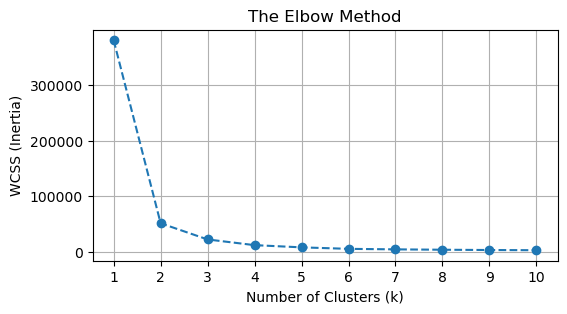

In [7]:
# Plot the Elbow Graph
plt.figure(figsize=(6, 3))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

#### Silhouette Analysis

In [8]:
inertia = []
silhouette_avg = []
range_n_clusters = range(2, 11) # Silhouette requires at least 2 clusters

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)
    
    # 1. Capture Inertia (for Elbow)
    inertia.append(kmeans.inertia_)
    
    # 2. Capture Silhouette Score
    silhouette_avg.append(silhouette_score(X, cluster_labels))



#### Visualization : Silhouette

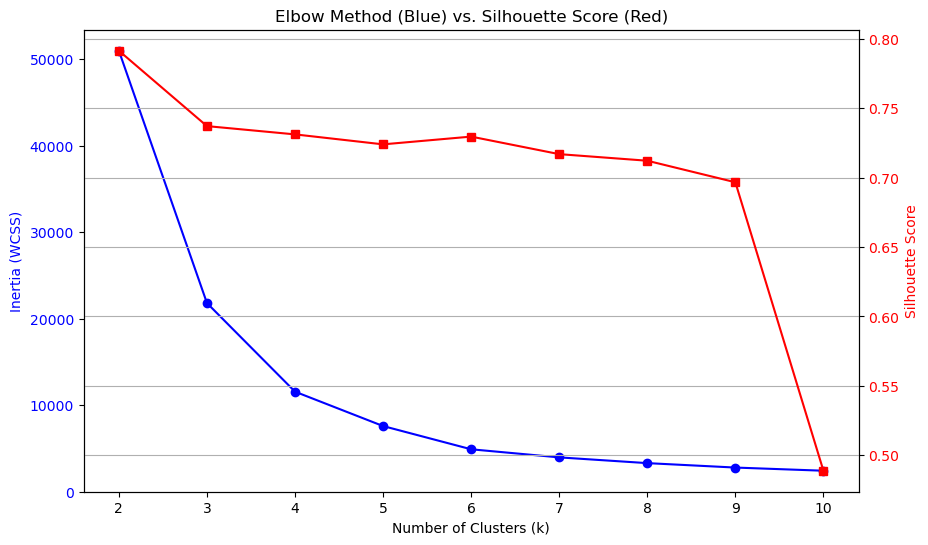

In [9]:
# Plotting the comparison
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot WCSS (Inertia)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (WCSS)', color='blue')
ax1.plot(range_n_clusters, inertia, color='blue', marker='o', label='Inertia')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis for Silhouette Score
ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='red')
ax2.plot(range_n_clusters, silhouette_avg, color='red', marker='s', label='Silhouette')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Elbow Method (Blue) vs. Silhouette Score (Red)')
plt.grid(True)
plt.show()

### BIC (Bayesian Information Criterion)

BIC is a metric used to select among a finite set of models. It balances how well the model fits the data against how many parameters (complexity) the model uses.

#### The Goal: 
We want the model with the lowest BIC score

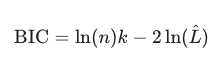

−2ln( 
L
^
 ) (The Penalty for Poor Fit): This is based on the Log-Likelihood. If your bell curves don't cover the data points well, this number gets very large. We want this to be low.

ln(n)k (The Penalty for Complexity): * n = Number of data points.

k = Number of parameters (Means, Variances, etc.).

Logic: Every time you add a new cluster, you add more parameters. BIC "punishes" you for adding clusters that don't significantly improve the fit.

#### Example :
### Cluster (k=1)
#### We need to estimate 1 mean (μ) and 1 variance (σ 2). So, k=2.
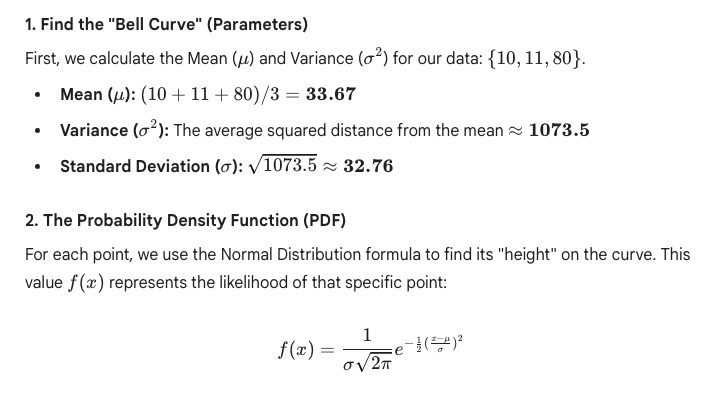

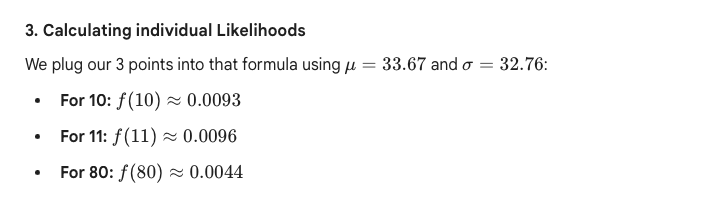

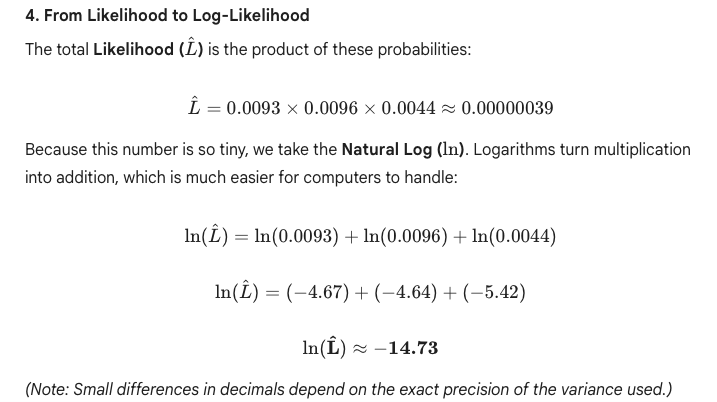

#### BIC=(1.0986×2)−2(−14.72)
#### BIC=2.197+29.44
#### BIC≈31.64

### Clusters (k=2)
#### We need 2 means, 2 variances, and 1 mixing weight (the probability of being in group 1 vs group 2). So, k=5.

#### BIC=(1.0986×5)−2(2.63)
#### BIC=5.493−5.26
#### BIC≈0.23

Even though the 2-cluster model is more "complex" (it has 5 parameters instead of 2), the Fit Penalty for the 1-cluster model is so massive that the 2-cluster model wins easily.

Statistically, k=2 is the optimal choice for this data.

To calculate the responsibility (E-step), you need the cluster parameters. But to find the cluster parameters (M-step), you need the responsibility.

The Starting Line (Initialization):
Before the first E-step, the model doesn't "know" anything about Budget or Premium. It has to make a guess. There are two common ways it does this,

#### K-Means Initialization (The Standard): 
By default, scikit-learn runs a quick K-Means algorithm first.

K-Means groups the points into {10,11} and {80}.

The GMM then uses those K-Means groups to calculate its first μ, σ 
2
 , and π.
 
#### Random Initialization: 
It picks k random data points to be the means, sets the variance to be the total variance of the whole dataset, and gives each cluster an equal weight (π=0.5).

#### Statistical example :

How our specific numbers were born

In our 3-point example (10,11,80), let's look at how the model reached those exact numbers (μ=10.5,σ 
2
 =0.25) during its first "pass":

##### The Mean (μ)

The model looked at the points it "assigned" to the first group (10 and 11).

μ= (10+11)/2 =10.5
##### The Variance (σ^2)

It measured the average squared distance of those points from 10.5:

Distance for 10: (10−10.5)^2 =0.25
Distance for 11: (11−10.5)^2 =0.25

    σ^2 = (0.25+0.25)/2 =0.25

##### The Weight (π)
It counted how many points were in that group out of the total:

Two points in Cluster 0.
One point in Cluster 1.

π0 = 2/3 ≈0.66,π = 1/3 ≈0.33

##### The "Singularity" Problem
You might have noticed that for Cluster 1 (the 80), if we apply the same variance math μ=80
Distance for 80:(80−80)^2 =0, 
Statistically, this is a disaster. A variance of 0 makes the "height" of the bell curve infinite. This is called a Singularity.

To prevent this from crashing, GMM models add a tiny "regulator" (usually 1×10^−6) to the variance. That’s why in my previous example, I used σ^2 1 = 1.0
just to keep the math easy to follow and prevent the bell curve from becoming an infinitely thin needle!

The model didn't "decide" those numbers out of thin air; it observed the initial clusters (often provided by K-Means) and calculated the average, spread, and size of those groups to use as the "Base Case" for the first iteration of the EM loop.

Conclusion, K-means is a good estimator for begining of EM algorithm in GMM. By K-means parameter we can initialize mean,variance and weight.

#### Statistical example of GMM through the lens of the EM Algorithm (Expectation-Maximization)
data {10,11,80}

1. The Setup: Two "Competent" Gaussians

GMM assumes these points were generated by two different bell curves (Gaussians).
Gaussian 0 (Budget): High density, centered around 10.5.
Gaussian 1 (Premium): High density, centered around 80.

2. The Expectation Step (E-Step): "Responsibility"

Instead of a distance table, we create a Responsibility (γ) Table. This represents the probability that a specific Gaussian "claims" a data point.
For a point x 
i
​	
 , the responsibility of cluster k is:
 
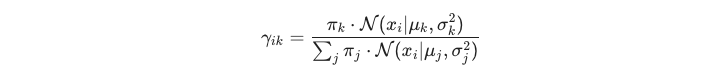

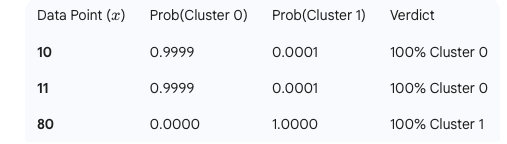

#### How above table is calculated?
lets consider x = 10

Cluster 0 (Budget): Mean μ0 = 10.5, Variance σ^2 0 =0.25 (so σ0 =0.5), Weight π0 =0.66

Cluster 1 (Premium): Mean μ1 = 80, Variance σ^2 1 =1.0, Weight π1=0.33

#### Step 1: Calculate the "Density" (Height) for each Cluster

We use the Probability Density Function (PDF) for a Normal Distribution:

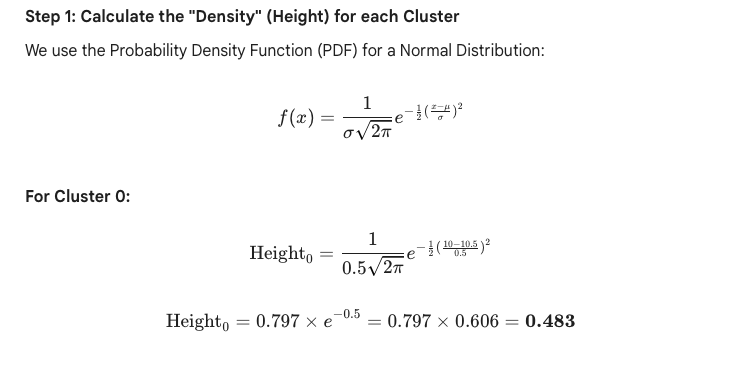

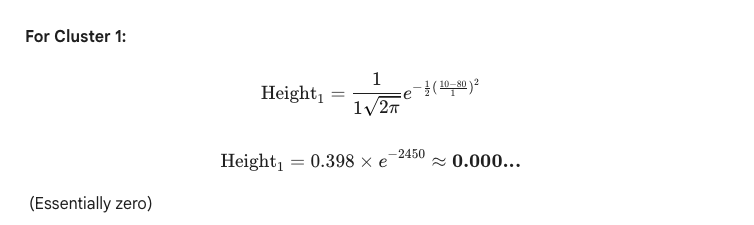

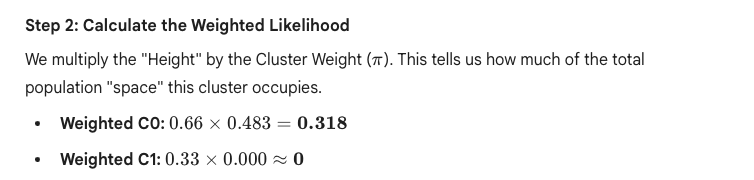

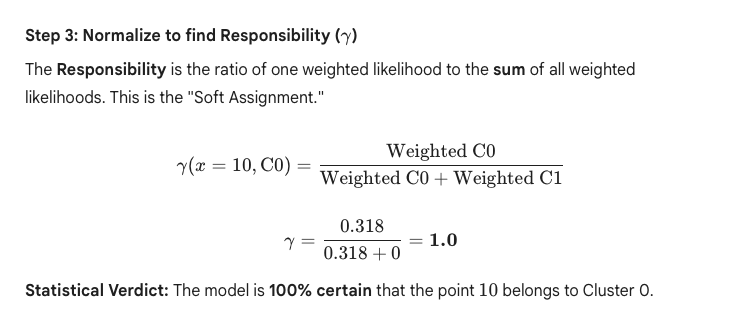

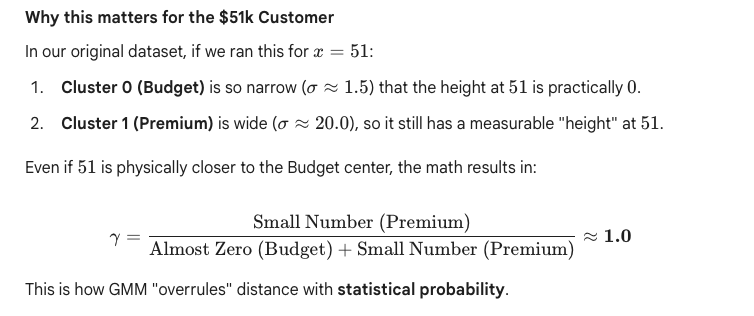

##### Maximization Step (M-Step), 
the model takes those "Responsibility" scores we just calculated and uses them to re-adjust its world view. It’s like a democratic election where every data point gets to "vote" on where the cluster centers should be, but their vote is weighted by their responsibility score.

#### Statistical example,

We will use our 3 data points (10,11,80) to see how Cluster 0 (Budget) updates its Mean (μ) and Variance (σ^2).

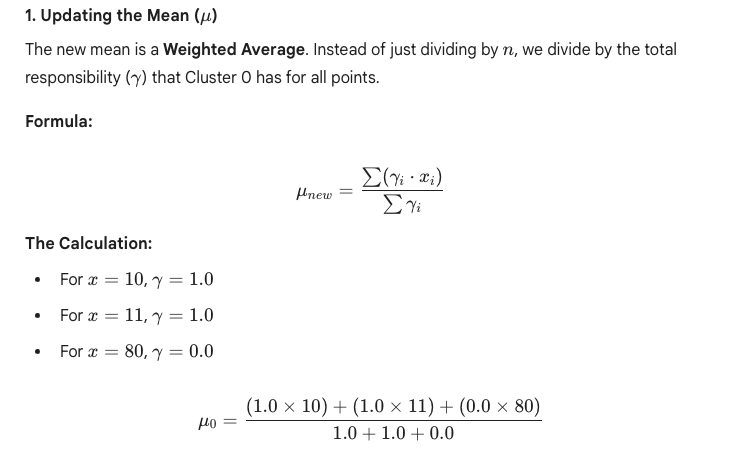

μ0= 21/2 =10.5

Statistical Insight: Notice how the 80 had zero influence on this mean. Because the E-step decided the 80 didn't belong to Cluster 0, the Budget center stayed perfectly centered between 10 and 11.

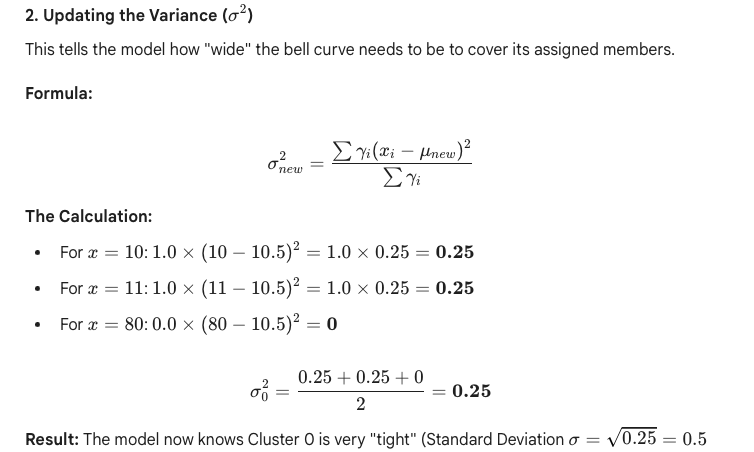

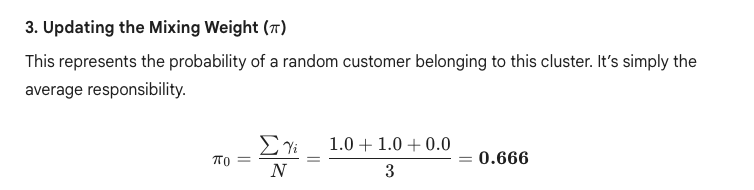

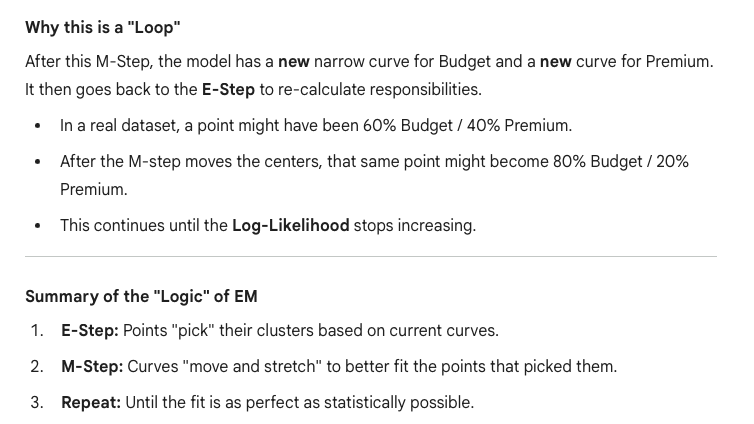

### 3. APPLY GMM (Probabilistic/EM Logic)
# -------------------------------------------

In [10]:
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(X)

# Assign hard labels and soft probabilities
df['GMM_Labels'] = gmm.predict(X)
probs = gmm.predict_proba(X)
# We store the probability of being in each cluster
df['Prob_C0'] = probs[:, 0]
df['Prob_C1'] = probs[:, 1]



In [11]:
df.head()

,Annual Spend (k$),Purchase Frequency (Score),True Label,KMeans_Labels,GMM_Labels,Prob_C0,Prob_C1
0,20.993428,6.930868,Budget Friendly,0,0,0.999967,0.000033
1,21.295377,7.761515,Budget Friendly,0,0,0.999952,0.000048
2,19.531693,6.882932,Budget Friendly,0,0,0.999976,0.000024
3,23.158426,7.383717,Budget Friendly,0,0,0.999863,0.000137
4,19.061051,7.271280,Budget Friendly,0,0,0.999982,0.000018


### 4. PREDICTING THE NEW CUSTOMER (The $51k Disputed Case)
# -------------------------------------------

In [12]:

new_customer = np.array([[51.0, 5.5]])

# Identify which cluster index is "Premium" (higher mean spend)
km_premium_idx = np.argmax(kmeans.cluster_centers_[:, 0])
gmm_premium_idx = np.argmax(gmm.means_[:, 0])

km_val = kmeans.predict(new_customer)[0]
gmm_val = gmm.predict(new_customer)[0]
gmm_final_probs = gmm.predict_proba(new_customer)[0]

# Mapping to human-readable names
km_res = "Premium" if km_val == km_premium_idx else "Budget Friendly"
gmm_res = "Premium" if gmm_val == gmm_premium_idx else "Budget Friendly"



### 5. OUTPUT RESULTS
# -------------------------------------------

In [13]:

print("--- MODEL VERDICTS FOR NEW CUSTOMER ($51k Spend, 5.5 Freq) ---")
print(f"K-Means Verdict: {km_res}")
print(f"GMM Verdict:     {gmm_res}")
print(f"GMM Confidence (Premium): {gmm_final_probs[gmm_premium_idx]:.4%}")
print("-" * 60)

# Statistical Check: Why did they differ?
dist_to_budget = np.linalg.norm(new_customer - kmeans.cluster_centers_[1-km_premium_idx])
dist_to_premium = np.linalg.norm(new_customer - kmeans.cluster_centers_[km_premium_idx])

print(f"Euclidean Distance to Budget Center: {dist_to_budget:.2f}")
print(f"Euclidean Distance to Premium Center: {dist_to_premium:.2f}")

--- MODEL VERDICTS FOR NEW CUSTOMER ($51k Spend, 5.5 Freq) ---
K-Means Verdict: Budget Friendly
GMM Verdict:     Premium
GMM Confidence (Premium): 100.0000%
------------------------------------------------------------
Euclidean Distance to Budget Center: 61.81
Euclidean Distance to Premium Center: 79.80


### Clustering Strategy Map

#### Phase 1: The "Guessing" Phase (K-Means)

You start with K-Means because it is fast and gives you a baseline.

The Goal: Find hard boundaries between groups.

The Metric (Inertia/WCSS): You run the model for k=1 to k=10. You look for the Elbow where the "tightness" of the clusters stops improving significantly.

The Validation (Silhouette Score): You check if the clusters are actually distinct. If the score is high (near 1.0), your "Islands" are well-separated.

#### Phase 2: The "Refining" Phase (GMM)

If your Silhouette plot shows "confused" points (scores near 0) or your clusters have different shapes, you move to Gaussian Mixture Models (GMM).

The Engine (EM Algorithm):

E-Step: Uses the PDF (Probability Density Function) to calculate the "height" of the bell curve for each point and assign Responsibility.

M-Step: Re-calculates the Mean and Variance based on those responsibilities.

The Decision Metric (BIC): Since GMM is more complex than K-Means, you use BIC to make sure you aren't "overfitting." You pick the k with the lowest BIC.

#### Phase 3: The Business Workflow Map

Here is how all the terms we discussed fit into the "Logic Chain":



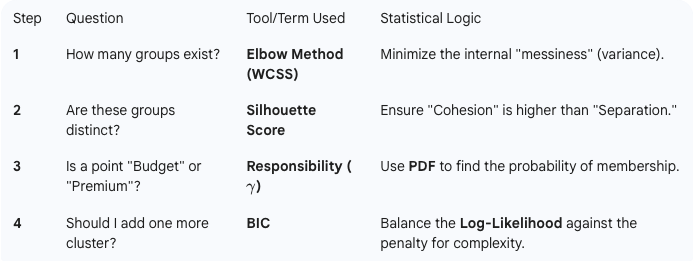

#### The "Big Picture" Visual

Imagine your data points on a map:

1. WCSS is the ruler measuring how far points are from the center of their town.
2. Silhouette is the fence between two towns.
3. PDF is the "weather map" showing the density of people in the town.
4. EM is the process of people moving houses until everyone is in the town that fits them best.
5. BIC is the auditor who says, "We don't need to build a 3rd town for just one person; it's too expensive (complex)."

In [14]:

n_clusters = range(2, 9)
inertia = []
silhouette_scores = []
bic_scores = []

for k in n_clusters:
    # K-Means Metrics
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels_km = km.fit_predict(X)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X, labels_km))
    
    # GMM Metrics
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X)
    bic_scores.append(gmm.bic(X))



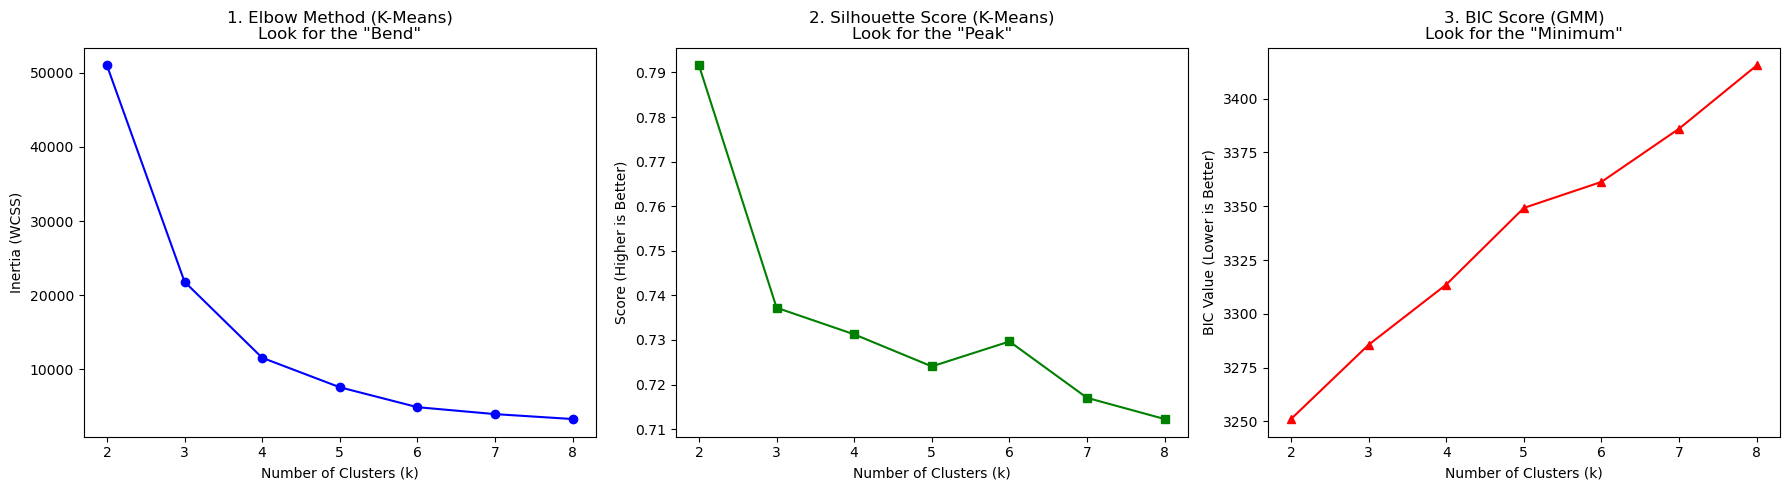

In [15]:

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Elbow Method (WCSS)
ax[0].plot(n_clusters, inertia, marker='o', color='blue')
ax[0].set_title('1. Elbow Method (K-Means)\nLook for the "Bend"')
ax[0].set_xlabel('Number of Clusters (k)')
ax[0].set_ylabel('Inertia (WCSS)')

# Plot 2: Silhouette Score
ax[1].plot(n_clusters, silhouette_scores, marker='s', color='green')
ax[1].set_title('2. Silhouette Score (K-Means)\nLook for the "Peak"')
ax[1].set_xlabel('Number of Clusters (k)')
ax[1].set_ylabel('Score (Higher is Better)')

# Plot 3: BIC Score
ax[2].plot(n_clusters, bic_scores, marker='^', color='red')
ax[2].set_title('3. BIC Score (GMM)\nLook for the "Minimum"')
ax[2].set_xlabel('Number of Clusters (k)')
ax[2].set_ylabel('BIC Value (Lower is Better)')

plt.tight_layout()
plt.show()

1. The Elbow (Blue): You will see a sharp drop from k=1 to k=2. After k=2, the line becomes much flatter. This tells you that two centers explain most of the "spread" in your data.

2. The Silhouette (Green): The peak should happen exactly at k=2. This confirms that the Budget and Premium groups are physically separated enough that they don't overlap in a confusing way.

3. The BIC (Red): The curve will dip and hit its lowest point at k=2. This is the statistical "Goldilocks" zone—it has enough clusters to explain the data (High Likelihood) without being unnecessarily complex (Low Penalty).

Centroid: 
The "Average" location (20.1k,84.8k).

WCSS/Inertia: 
The "Tightness" of the group.

Silhouette: 
The "Distance" between groups.

BIC: 
The "Balance" between accuracy and complexity.

EM: 
The "Process" of moving the curves to fit the points.